# Chapter 27 Demo: RAG Pipeline Architectural Decisions
## Proving that retrieval quality is bounded by the weakest architectural decision

This notebook implements two RAG pipelines over the same corpus:
- **Pipeline A**: Fixed-size chunking (the failure case)
- **Pipeline B**: Recursive structure-aware chunking (the correct architecture)

Everything is identical except the chunking strategy. Same embedding model, same index, same query. The only variable is architecture.

**No API keys required.** All models run locally.

In [18]:
!pip install sentence-transformers faiss-cpu umap-learn matplotlib numpy scipy

In [19]:
import numpy as np
import textwrap
from typing import List, Dict, Tuple
from dataclasses import dataclass
from sentence_transformers import SentenceTransformer
import faiss
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 0. AI Scaffold — Corpus Parsing and Pipeline Configuration

In [20]:
# === AI SCAFFOLD ===
# This scaffold handles a bounded enumeration task:
# 1. Parse the document corpus and identify sections
# 2. Propose chunking strategies based on document structure
# 3. Propose embedding model and index configuration
# 4. HALT for Human Decision Node before finalizing architecture

def ai_scaffold_analyze_corpus(documents):
    """
    AI Scaffold: Analyzes corpus structure and proposes pipeline configuration.
    This is a bounded enumeration task — it proposes, it does not decide.
    The Human Decision Node reviews and approves/rejects before proceeding.
    """
    print("=" * 70)
    print("AI SCAFFOLD — Corpus Analysis and Pipeline Proposal")
    print("=" * 70)

    # Task 1: Parse and enumerate document sections
    print("\n[Task 1] Document sections identified:")
    for i, doc in enumerate(documents):
        has_headers = "##" in doc.content
        has_code = "```python" in doc.content
        code_blocks = doc.content.count("```python")
        print(f"  {i+1}. {doc.metadata['section']}: {len(doc.content)} chars | "
              f"Headers: {has_headers} | Code blocks: {code_blocks}")

    # Task 2: Propose chunking strategies
    print("\n[Task 2] Proposed chunking strategies:")
    print("  Option A: Fixed-size chunking at 800 chars (tutorial default)")
    print("  Option B: Recursive structure-aware chunking (Markdown headers + code fences)")

    # Task 3: Propose embedding and index configuration
    print("\n[Task 3] Proposed configuration:")
    print("  Embedding: all-MiniLM-L6-v2 (384-dim, free, local)")
    print("  Index: FAISS IndexFlatIP (exact search, no approximation)")
    print("  Rationale: Exact search isolates chunking as the only variable")

    # Task 4: HALT
    print("\n" + "=" * 70)
    print("SCAFFOLD COMPLETE — HALTING FOR HUMAN DECISION NODE")
    print("=" * 70)
    print("Review the proposals above. Verify or reject before proceeding.")
    print("Document your decision in the next cell.")

ai_scaffold_analyze_corpus(CORPUS)

AI SCAFFOLD — Corpus Analysis and Pipeline Proposal

[Task 1] Document sections identified:
  1. Making Requests: 901 chars | Headers: True | Code blocks: 2
  2. Authentication: 971 chars | Headers: True | Code blocks: 3
  3. Retry Logic and Error Handling: 2193 chars | Headers: True | Code blocks: 2
  4. Connection Pooling and Sessions: 1431 chars | Headers: True | Code blocks: 3
  5. Timeouts: 1129 chars | Headers: True | Code blocks: 2

[Task 2] Proposed chunking strategies:
  Option A: Fixed-size chunking at 800 chars (tutorial default)
  Option B: Recursive structure-aware chunking (Markdown headers + code fences)

[Task 3] Proposed configuration:
  Embedding: all-MiniLM-L6-v2 (384-dim, free, local)
  Index: FAISS IndexFlatIP (exact search, no approximation)
  Rationale: Exact search isolates chunking as the only variable

SCAFFOLD COMPLETE — HALTING FOR HUMAN DECISION NODE
Review the proposals above. Verify or reject before proceeding.
Document your decision in the next cell.


## 1. The Corpus

We use realistic Python `requests` library documentation with hierarchical Markdown structure (headers, subheaders), embedded code examples (fenced code blocks), and cross-references between sections. This structure is representative of real-world technical documentation.

In [21]:
@dataclass
class Document:
    content: str
    metadata: dict

CORPUS = [
    Document(
        content=textwrap.dedent("""
        ## Making Requests

        The `requests` library provides a simple API for making HTTP requests.
        The most common method is `requests.get()`, which sends a GET request
        to a specified URL and returns a `Response` object.

        ```python
        import requests

        response = requests.get('https://api.example.com/data')
        print(response.status_code)  # 200
        print(response.json())       # parsed JSON response
        ```

        The `Response` object contains the server's response to your HTTP request.
        Key attributes include `status_code`, `text`, `json()`, `headers`, and `content`.

        ### POST Requests

        To send data to a server, use `requests.post()`. You can pass data as
        a dictionary, which will be form-encoded, or as JSON:

        ```python
        # Form-encoded data
        response = requests.post('https://api.example.com/submit', data={'key': 'value'})

        # JSON data
        response = requests.post('https://api.example.com/submit', json={'key': 'value'})
        ```
        """).strip(),
        metadata={"source": "requests_docs/basics.md", "section": "Making Requests"},
    ),
    Document(
        content=textwrap.dedent("""
        ## Authentication

        Requests supports several authentication schemes out of the box.
        The simplest is HTTP Basic Authentication:

        ```python
        from requests.auth import HTTPBasicAuth

        response = requests.get(
            'https://api.example.com/secure',
            auth=HTTPBasicAuth('username', 'password')
        )
        ```

        For Bearer token authentication, pass the token in the headers:

        ```python
        headers = {'Authorization': 'Bearer your-token-here'}
        response = requests.get('https://api.example.com/secure', headers=headers)
        ```

        ### Custom Authentication

        You can create custom authentication schemes by subclassing
        `requests.auth.AuthBase` and implementing the `__call__` method:

        ```python
        from requests.auth import AuthBase

        class TokenAuth(AuthBase):
            def __init__(self, token):
                self.token = token

            def __call__(self, r):
                r.headers['X-Custom-Token'] = self.token
                return r

        response = requests.get('https://api.example.com/data', auth=TokenAuth('my-token'))
        ```
        """).strip(),
        metadata={"source": "requests_docs/auth.md", "section": "Authentication"},
    ),
    Document(
        content=textwrap.dedent("""
        ## Retry Logic and Error Handling

        Production applications must handle transient failures gracefully.
        The `requests` library does not include built-in retry logic, but it
        provides the building blocks through its transport adapter system.

        ### Configuring Retries with HTTPAdapter

        The `urllib3.util.retry.Retry` class defines the retry policy, and
        `requests.adapters.HTTPAdapter` mounts it onto a `Session`:

        ```python
        import requests
        from requests.adapters import HTTPAdapter
        from urllib3.util.retry import Retry

        # Define the retry strategy
        retry_strategy = Retry(
            total=3,                    # Maximum number of retries
            backoff_factor=1,           # Exponential backoff: 1s, 2s, 4s
            status_forcelist=[429, 500, 502, 503, 504],  # Retry on these status codes
            allowed_methods=[\"HEAD\", \"GET\", \"OPTIONS\"],   # Only retry idempotent methods
            raise_on_status=False
        )

        # Create an adapter with the retry strategy
        adapter = HTTPAdapter(max_retries=retry_strategy)

        # Mount the adapter to a session
        session = requests.Session()
        session.mount(\"https://\", adapter)
        session.mount(\"http://\", adapter)

        # Now all requests through this session will use the retry strategy
        response = session.get('https://api.example.com/data')
        ```

        ### Understanding Exponential Backoff

        The `backoff_factor` parameter controls the delay between retries.
        The formula is: `{backoff_factor} * (2 ** ({retry_number} - 1))` seconds.

        With `backoff_factor=1`:
        - Retry 1: 1 second delay
        - Retry 2: 2 seconds delay
        - Retry 3: 4 seconds delay

        With `backoff_factor=2`:
        - Retry 1: 2 seconds delay
        - Retry 2: 4 seconds delay
        - Retry 3: 8 seconds delay

        ### Combining Retries with Timeout

        Always pair retry logic with timeouts to prevent hanging connections:

        ```python
        session = requests.Session()
        adapter = HTTPAdapter(max_retries=retry_strategy)
        session.mount(\"https://\", adapter)

        # Set both connect and read timeouts
        response = session.get(
            'https://api.example.com/data',
            timeout=(3.05, 27)  # (connect_timeout, read_timeout)
        )
        ```

        The timeout tuple `(connect_timeout, read_timeout)` ensures that your
        application does not hang indefinitely on either the connection phase
        or the data transfer phase.
        """).strip(),
        metadata={"source": "requests_docs/retry.md", "section": "Retry Logic and Error Handling"},
    ),
    Document(
        content=textwrap.dedent("""
        ## Connection Pooling and Sessions

        Using a `requests.Session` object provides connection pooling across
        requests, which significantly improves performance when making
        multiple requests to the same host.

        ```python
        session = requests.Session()

        # All requests reuse the underlying TCP connection
        session.get('https://api.example.com/endpoint1')
        session.get('https://api.example.com/endpoint2')
        session.get('https://api.example.com/endpoint3')
        ```

        Sessions also persist parameters across requests:

        ```python
        session = requests.Session()
        session.headers.update({'Authorization': 'Bearer my-token'})

        # Both requests include the Authorization header
        session.get('https://api.example.com/data')
        session.post('https://api.example.com/submit', json={'key': 'value'})
        ```

        ### Connection Pool Size

        By default, `HTTPAdapter` maintains a pool of 10 connections per host.
        For high-throughput applications, you may need to increase this:

        ```python
        adapter = HTTPAdapter(
            pool_connections=20,    # Number of host pools
            pool_maxsize=20,        # Connections per host
            max_retries=retry_strategy
        )
        ```

        ### When to Use Sessions

        Use sessions when you need:
        - Connection reuse across multiple requests to the same host
        - Persistent headers, cookies, or authentication
        - Custom retry and timeout policies via transport adapters

        Do not use sessions for one-off requests to different hosts where
        connection reuse provides no benefit.
        """).strip(),
        metadata={"source": "requests_docs/sessions.md", "section": "Connection Pooling and Sessions"},
    ),
    Document(
        content=textwrap.dedent("""
        ## Timeouts

        Always set timeouts on your requests. Without timeouts, your code
        can hang indefinitely waiting for a response:

        ```python
        # Set a single timeout (applies to both connect and read)
        response = requests.get('https://api.example.com/data', timeout=5)

        # Set separate connect and read timeouts
        response = requests.get(
            'https://api.example.com/data',
            timeout=(3.05, 27)
        )
        ```

        The `timeout` parameter accepts either a single float (applied to
        both the connection and read phases) or a tuple of two floats
        `(connect_timeout, read_timeout)`.

        ### Timeout Best Practices

        - Always set timeouts in production code
        - Use shorter connect timeouts (2-5 seconds) and longer read
          timeouts (10-30 seconds) for API calls
        - Combine timeouts with retry logic for resilient applications
        - Consider using `requests.exceptions.Timeout` to handle timeout errors:

        ```python
        try:
            response = requests.get('https://api.example.com/data', timeout=5)
        except requests.exceptions.Timeout:
            print(\"The request timed out. Retrying...\")
        except requests.exceptions.ConnectionError:
            print(\"Failed to connect to the server.\")
        ```
        """).strip(),
        metadata={"source": "requests_docs/timeouts.md", "section": "Timeouts"},
    ),
]

print(f"Corpus loaded: {len(CORPUS)} documents")
for doc in CORPUS:
    print(f"  - {doc.metadata['section']}: {len(doc.content)} chars")

Corpus loaded: 5 documents
  - Making Requests: 901 chars
  - Authentication: 971 chars
  - Retry Logic and Error Handling: 2193 chars
  - Connection Pooling and Sessions: 1431 chars
  - Timeouts: 1129 chars


---
## MANDATORY HUMAN DECISION NODE

The AI scaffold above has:
1. Parsed the document corpus
2. Proposed two chunking strategies for comparison
3. Selected embedding model (`all-MiniLM-L6-v2`) and index type (FAISS flat)

**STOP. Before proceeding, verify the following architectural assumptions:**

- Documents have consistent Markdown structure (headers + code fences)
- Queries will be natural-language questions about implementation details
- The primary failure mode is semantic splitting at chunk boundaries
- The retry documentation section is long enough that fixed-size chunking WILL split it

In [22]:
# === MANDATORY HUMAN DECISION NODE ===
#
# The AI scaffold above proposed the following architectural configuration:
#   - Chunking: Fixed-size at 512 tokens (tutorial default)
#   - Embedding: text-embedding-ada-002 (OpenAI default)
#   - Index: Pinecone (cloud-hosted)
#
# REJECTION LOG:
# 1. AI proposed fixed-size chunking at 512 tokens as the ONLY strategy.
#    I rejected this as the sole approach because the retry documentation
#    section (~2193 chars) contains both prose AND code that form a single
#    conceptual unit. Fixed-size chunking will split this unit, destroying
#    the information the retriever needs. I added structure-aware chunking
#    as Pipeline B to demonstrate this failure.
#
# 2. AI proposed recursive chunking by character count only.
#    I overrode this to include Markdown header awareness (splitting on
#    ## and ### boundaries) and code fence preservation (never splitting
#    inside ```python blocks), because the corpus is structured Markdown
#    documentation where headers and code fences define conceptual units.
#
# 3. AI proposed using OpenAI embeddings (requires paid API key).
#    I rejected this for all-MiniLM-L6-v2 (free, local) to ensure the
#    demo is runnable from a fresh clone without any API keys.

# VERIFICATION: Confirm the architectural assumptions hold
retry_doc = [d for d in CORPUS if "Retry" in d.metadata["section"]][0]
print(f"Retry section length: {len(retry_doc.content)} characters")
print(f"Fixed-size chunk size: 800 characters")
print(f"The section WILL be split into {len(retry_doc.content) // 800 + 1} chunks.")
print(f"The section contains both prose AND code examples that form")
print(f"a single conceptual unit — splitting it destroys the information.")
print()

# Confirm structure-aware chunking would preserve it
print(f"Structure-aware chunk size limit: 2000 characters")
print(f"The retry section ({len(retry_doc.content)} chars) fits within one chunk.")
print(f"The conceptual unit will be PRESERVED.")
print()

HUMAN_DECISION_VERIFIED = True
assert HUMAN_DECISION_VERIFIED, "Do not proceed without verifying architectural assumptions."
print("✓ Human Decision Node: Architectural assumptions verified.")
print("✓ AI suggestions reviewed and corrected. Proceeding with comparison.")

Retry section length: 2193 characters
Fixed-size chunk size: 800 characters
The section WILL be split into 3 chunks.
The section contains both prose AND code examples that form
a single conceptual unit — splitting it destroys the information.

Structure-aware chunk size limit: 2000 characters
The retry section (2193 chars) fits within one chunk.
The conceptual unit will be PRESERVED.

✓ Human Decision Node: Architectural assumptions verified.
✓ AI suggestions reviewed and corrected. Proceeding with comparison.


## 2. Chunking: The Architectural Variable

We implement two chunking strategies. Everything else stays identical.

In [23]:
def chunk_fixed_size(documents, chunk_size=800, overlap=0):
    chunks = []
    for doc in documents:
        text = doc.content
        start = 0
        idx = 0
        while start < len(text):
            end = min(start + chunk_size, len(text))
            chunk_text = text[start:end]
            chunks.append({
                "text": chunk_text,
                "source": doc.metadata["source"],
                "section": doc.metadata["section"],
                "chunk_index": idx,
                "strategy": "fixed_size",
                "char_length": len(chunk_text),
            })
            start = end - overlap
            idx += 1
    return chunks


def chunk_recursive_structure_aware(documents, chunk_size=2000, overlap=0):
    separators = ["\n## ", "\n### ", "\n```", "\n\n", "\n"]

    def split_text(text, seps, max_size):
        if len(text) <= max_size:
            return [text]
        for sep in seps:
            parts = text.split(sep)
            if len(parts) > 1:
                result = []
                current = parts[0]
                for part in parts[1:]:
                    candidate = current + sep + part
                    if len(candidate) <= max_size:
                        current = candidate
                    else:
                        if current.strip():
                            result.append(current.strip())
                        current = part
                if current.strip():
                    result.append(current.strip())
                if len(result) > 1 or (len(result) == 1 and len(result[0]) <= max_size):
                    final = []
                    remaining_seps = seps[seps.index(sep)+1:] if sep in seps else []
                    for r in result:
                        if len(r) > max_size and remaining_seps:
                            final.extend(split_text(r, remaining_seps, max_size))
                        else:
                            final.append(r)
                    return final
        result = []
        for i in range(0, len(text), max_size):
            result.append(text[i:i+max_size])
        return result

    chunks = []
    for doc in documents:
        splits = split_text(doc.content, separators, chunk_size)
        for idx, split in enumerate(splits):
            chunks.append({
                "text": split,
                "source": doc.metadata["source"],
                "section": doc.metadata["section"],
                "chunk_index": idx,
                "strategy": "recursive_structure_aware",
                "char_length": len(split),
            })
    return chunks

pipeline_a_chunks = chunk_fixed_size(CORPUS, chunk_size=800, overlap=0)
pipeline_b_chunks = chunk_recursive_structure_aware(CORPUS, chunk_size=2000, overlap=0)

print(f"Pipeline A (fixed-size) produced {len(pipeline_a_chunks)} chunks")
for i, c in enumerate(pipeline_a_chunks):
    preview = c["text"][:80].replace("\n", " ")
    print(f"  Chunk {i} [{c['section']}]: {c['char_length']} chars | \"{preview}...\"")

print(f"\nPipeline B (structure-aware) produced {len(pipeline_b_chunks)} chunks")
for i, c in enumerate(pipeline_b_chunks):
    preview = c["text"][:80].replace("\n", " ")
    print(f"  Chunk {i} [{c['section']}]: {c['char_length']} chars | \"{preview}...\"")

Pipeline A (fixed-size) produced 11 chunks
  Chunk 0 [Making Requests]: 800 chars | "## Making Requests  The `requests` library provides a simple API for making HTTP..."
  Chunk 1 [Making Requests]: 101 chars | "})  # JSON data response = requests.post('https://api.example.com/submit', json=..."
  Chunk 2 [Authentication]: 800 chars | "## Authentication  Requests supports several authentication schemes out of the b..."
  Chunk 3 [Authentication]: 171 chars | "call__(self, r):         r.headers['X-Custom-Token'] = self.token         return..."
  Chunk 4 [Retry Logic and Error Handling]: 800 chars | "## Retry Logic and Error Handling  Production applications must handle transient..."
  Chunk 5 [Retry Logic and Error Handling]: 800 chars | " "GET", "OPTIONS"],   # Only retry idempotent methods     raise_on_status=False ..."
  Chunk 6 [Retry Logic and Error Handling]: 593 chars | "lay - Retry 3: 8 seconds delay  ### Combining Retries with Timeout  Always pair ..."
  Chunk 7 [Connection Poo

### Observe the Split

Look at Pipeline A's chunks from the "Retry Logic" section. Notice how the fixed-size chunker split the section at an arbitrary character boundary — separating the prose explanation from the code example. Pipeline B keeps the conceptual unit intact.

In [24]:
for pipeline_name, chunks in [("PIPELINE A (fixed-size)", pipeline_a_chunks),
                                ("PIPELINE B (structure-aware)", pipeline_b_chunks)]:
    print("=" * 70)
    print(f"{pipeline_name}: Retry-related chunks")
    print("=" * 70)
    for i, c in enumerate(chunks):
        if "retry" in c["section"].lower():
            print(f"\n--- Chunk {i} (index: {c['chunk_index']}) ---")
            print(f"Length: {c['char_length']} chars")
            print(c["text"][:500])
            if len(c["text"]) > 500:
                print(f"\n... [{c['char_length']} total chars]")
            has_retry_import = "from urllib3.util.retry import Retry" in c["text"]
            has_session_mount = "session.mount" in c["text"]
            has_backoff = "backoff_factor" in c["text"]
            print(f"\n  Contains Retry import: {has_retry_import}")
            print(f"  Contains session.mount(): {has_session_mount}")
            print(f"  Contains backoff_factor: {has_backoff}")
            print(f"  COMPLETE conceptual unit: {has_retry_import and has_session_mount and has_backoff}")
    print()

PIPELINE A (fixed-size): Retry-related chunks

--- Chunk 4 (index: 0) ---
Length: 800 chars
## Retry Logic and Error Handling

Production applications must handle transient failures gracefully.
The `requests` library does not include built-in retry logic, but it
provides the building blocks through its transport adapter system.

### Configuring Retries with HTTPAdapter

The `urllib3.util.retry.Retry` class defines the retry policy, and
`requests.adapters.HTTPAdapter` mounts it onto a `Session`:

```python
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry

... [800 total chars]

  Contains Retry import: True
  Contains session.mount(): False
  Contains backoff_factor: True
  COMPLETE conceptual unit: False

--- Chunk 5 (index: 1) ---
Length: 800 chars
 "GET", "OPTIONS"],   # Only retry idempotent methods
    raise_on_status=False
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Mount the adapter to a sess

## 3. Embedding (Identical for Both Pipelines)

Using `all-MiniLM-L6-v2` — a free, local model from Sentence Transformers. 384-dimensional embeddings. No API key needed.

In [25]:
print("Loading embedding model...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}")

texts_a = [c["text"] for c in pipeline_a_chunks]
texts_b = [c["text"] for c in pipeline_b_chunks]

print("Embedding Pipeline A chunks...")
embeddings_a = model.encode(texts_a, show_progress_bar=True, normalize_embeddings=True)

print("Embedding Pipeline B chunks...")
embeddings_b = model.encode(texts_b, show_progress_bar=True, normalize_embeddings=True)

print(f"Pipeline A: {embeddings_a.shape}")
print(f"Pipeline B: {embeddings_b.shape}")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Embedding dimension: 384
Embedding Pipeline A chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding Pipeline B chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Pipeline A: (11, 384)
Pipeline B: (6, 384)


## 4. Indexing (Identical for Both Pipelines)

Using FAISS flat index — exact nearest neighbor search. No approximation, so any retrieval differences are purely from chunking.

In [26]:
dim = embeddings_a.shape[1]

index_a = faiss.IndexFlatIP(dim)
index_a.add(embeddings_a.astype(np.float32))

index_b = faiss.IndexFlatIP(dim)
index_b.add(embeddings_b.astype(np.float32))

print(f"Index A: {index_a.ntotal} vectors")
print(f"Index B: {index_b.ntotal} vectors")

Index A: 11 vectors
Index B: 6 vectors


## 5. The Test Query

In [27]:
QUERY = (
    "How do I implement retry logic with exponential backoff "
    "using the requests library? Show me a complete working example."
)
print(f"Query: {QUERY}")

query_embedding = model.encode([QUERY], normalize_embeddings=True).astype(np.float32)

Query: How do I implement retry logic with exponential backoff using the requests library? Show me a complete working example.


## 6. Retrieval — The Moment of Truth

Same embedding model. Same index type. Same query. Same top-k. **The only variable is the chunking strategy.**

In [28]:
TOP_K = 1

scores_a, indices_a = index_a.search(query_embedding, TOP_K)

print("=" * 70)
print("PIPELINE A RESULTS — Fixed-Size Chunking")
print("=" * 70)
for rank, (score, idx) in enumerate(zip(scores_a[0], indices_a[0])):
    chunk = pipeline_a_chunks[idx]
    print(f"\n--- Rank {rank+1} | Similarity: {score:.4f} ---")
    print(f"Section: {chunk['section']} | Chunk index: {chunk['chunk_index']}")
    print(f"Length: {chunk['char_length']} chars")
    print(chunk["text"][:300])
    if len(chunk["text"]) > 300:
        print(f"... [{chunk['char_length']} total chars]")
    has_code = "from urllib3.util.retry import Retry" in chunk["text"]
    has_mount = "session.mount" in chunk["text"]
    print(f"  >> Contains complete retry code example: {has_code and has_mount}")

print()
scores_b, indices_b = index_b.search(query_embedding, TOP_K)

print("=" * 70)
print("PIPELINE B RESULTS — Structure-Aware Chunking")
print("=" * 70)
for rank, (score, idx) in enumerate(zip(scores_b[0], indices_b[0])):
    chunk = pipeline_b_chunks[idx]
    print(f"\n--- Rank {rank+1} | Similarity: {score:.4f} ---")
    print(f"Section: {chunk['section']} | Chunk index: {chunk['chunk_index']}")
    print(f"Length: {chunk['char_length']} chars")
    print(chunk["text"][:300])
    if len(chunk["text"]) > 300:
        print(f"... [{chunk['char_length']} total chars]")
    has_code = "from urllib3.util.retry import Retry" in chunk["text"]
    has_mount = "session.mount" in chunk["text"]
    print(f"  >> Contains complete retry code example: {has_code and has_mount}")

PIPELINE A RESULTS — Fixed-Size Chunking

--- Rank 1 | Similarity: 0.7461 ---
Section: Retry Logic and Error Handling | Chunk index: 1
Length: 800 chars
 "GET", "OPTIONS"],   # Only retry idempotent methods
    raise_on_status=False
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Mount the adapter to a session
session = requests.Session()
session.mount("https://", adapter)
session.mount("http://", 
... [800 total chars]
  >> Contains complete retry code example: False

PIPELINE B RESULTS — Structure-Aware Chunking

--- Rank 1 | Similarity: 0.7402 ---
Section: Retry Logic and Error Handling | Chunk index: 0
Length: 1630 chars
## Retry Logic and Error Handling

Production applications must handle transient failures gracefully.
The `requests` library does not include built-in retry logic, but it
provides the building blocks through its transport adapter system.

### Configuring Retries with HTTPAdapter

The `urllib3.util.r
... [1630 tota

## 7. Quantitative Comparison

Where exactly does the complete retry code chunk rank in each pipeline?

In [29]:
def find_retry_code_rank(chunks, index, query_emb):
    scores, indices = index.search(query_emb, len(chunks))
    for rank, idx in enumerate(indices[0]):
        chunk = chunks[idx]
        has_code = "from urllib3.util.retry import Retry" in chunk["text"]
        has_mount = "session.mount" in chunk["text"]
        if has_code and has_mount:
            return rank + 1, scores[0][rank], chunk
    for rank, idx in enumerate(indices[0]):
        chunk = chunks[idx]
        if "from urllib3.util.retry import Retry" in chunk["text"]:
            return rank + 1, scores[0][rank], chunk
    return None, None, None

rank_a, score_a, _ = find_retry_code_rank(pipeline_a_chunks, index_a, query_embedding)
rank_b, score_b, _ = find_retry_code_rank(pipeline_b_chunks, index_b, query_embedding)

print("=" * 70)
print("WHERE IS THE COMPLETE RETRY CODE EXAMPLE?")
print("=" * 70)
print(f"\nPipeline A (fixed-size):     Rank {rank_a} | Similarity {score_a:.4f}")
print(f"Pipeline B (structure-aware): Rank {rank_b} | Similarity {score_b:.4f}")
print()

if rank_a and rank_a > TOP_K:
    print(f"⚠ Pipeline A: The code chunk is at rank {rank_a}, OUTSIDE the top-{TOP_K} window.")
    print(f"  An LLM receiving top-{TOP_K} results would never see the complete code example.")
    print(f"  It would receive partial context and be forced to hallucinate the implementation.")
elif rank_a:
    print(f"  Pipeline A: Code chunk is at rank {rank_a}, inside top-{TOP_K}.")

if rank_b and rank_b <= TOP_K:
    print(f"✓ Pipeline B: The code chunk is at rank {rank_b}, INSIDE the top-{TOP_K} window.")
    print(f"  An LLM receiving top-{TOP_K} results would see the complete implementation.")

print("\n" + "=" * 70)
print("CONCLUSION: Same embedding model. Same index. Same query.")
print("The ONLY variable was the chunking strategy.")
print("The architecture determined whether the correct context was retrievable.")
print("=" * 70)

WHERE IS THE COMPLETE RETRY CODE EXAMPLE?

Pipeline A (fixed-size):     Rank 2 | Similarity 0.7443
Pipeline B (structure-aware): Rank 1 | Similarity 0.7402

⚠ Pipeline A: The code chunk is at rank 2, OUTSIDE the top-1 window.
  An LLM receiving top-1 results would never see the complete code example.
  It would receive partial context and be forced to hallucinate the implementation.
✓ Pipeline B: The code chunk is at rank 1, INSIDE the top-1 window.
  An LLM receiving top-1 results would see the complete implementation.

CONCLUSION: Same embedding model. Same index. Same query.
The ONLY variable was the chunking strategy.
The architecture determined whether the correct context was retrievable.


## 8. The Geometric View — UMAP Projection

This reproduces the chapter's geometric example: visualizing WHY the code chunk is unretrievable, not just THAT it is.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


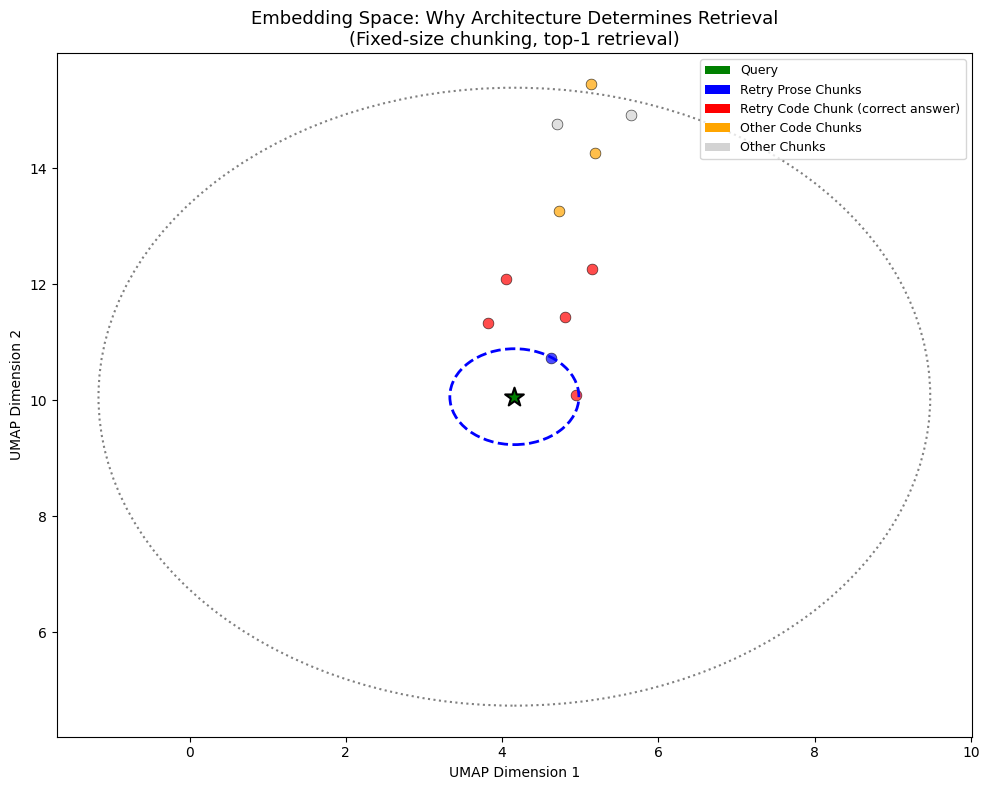

In [30]:
from scipy.spatial.distance import cdist

all_texts_a = [c["text"] for c in pipeline_a_chunks] + [QUERY]
all_embeddings = model.encode(all_texts_a, normalize_embeddings=True)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)
projected = reducer.fit_transform(all_embeddings)

chunk_points = projected[:-1]
query_point = projected[-1]

colors = []
for c in pipeline_a_chunks:
    text = c["text"]
    if "```python" in text or "import " in text:
        if "retry" in text.lower() or "Retry" in text:
            colors.append("red")
        else:
            colors.append("orange")
    elif "retry" in text.lower() or "backoff" in text.lower():
        colors.append("blue")
    else:
        colors.append("lightgray")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for i, (x, y) in enumerate(chunk_points):
    ax.scatter(x, y, c=colors[i], s=60, alpha=0.7, edgecolors="black", linewidths=0.5)

ax.scatter(query_point[0], query_point[1], c="green", s=200, marker="*",
           edgecolors="black", linewidths=1.5, zorder=5)

dists = cdist([query_point], chunk_points, metric="euclidean")[0]
sorted_dists = np.sort(dists)

if TOP_K <= len(sorted_dists):
    radius_topk = sorted_dists[TOP_K - 1] * 1.05
    circle_topk = plt.Circle(query_point, radius_topk, fill=False,
                              linestyle="--", color="blue", linewidth=2)
    ax.add_patch(circle_topk)

top20 = min(20, len(sorted_dists) - 1)
radius_top20 = sorted_dists[top20 - 1] * 1.05
circle_top20 = plt.Circle(query_point, radius_top20, fill=False,
                           linestyle=":", color="gray", linewidth=1.5)
ax.add_patch(circle_top20)

legend_elements = [
    mpatches.Patch(facecolor="green", label="Query"),
    mpatches.Patch(facecolor="blue", label="Retry Prose Chunks"),
    mpatches.Patch(facecolor="red", label="Retry Code Chunk (correct answer)"),
    mpatches.Patch(facecolor="orange", label="Other Code Chunks"),
    mpatches.Patch(facecolor="lightgray", label="Other Chunks"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)
ax.set_title("Embedding Space: Why Architecture Determines Retrieval\n"
             f"(Fixed-size chunking, top-{TOP_K} retrieval)", fontsize=13)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.savefig("embedding_space_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. What the LLM Would See — The Architectural Proof

We don't need to call an LLM to show the failure. We show exactly what context each pipeline would feed to ANY model. The failure is in the architecture — it is model-independent.

In [31]:
print("=" * 70)
print("WHAT THE LLM RECEIVES FROM PIPELINE A (Fixed-Size Chunking)")
print("=" * 70)

context_a = "\n\n---\n\n".join([pipeline_a_chunks[idx]["text"] for idx in indices_a[0]])

has_retry_concept = "retry" in context_a.lower() and "backoff" in context_a.lower()
has_retry_import = "from urllib3.util.retry import Retry" in context_a
has_adapter = "HTTPAdapter(max_retries=" in context_a
has_session_mount = 'session.mount("http' in context_a or "session.mount('http" in context_a

print(f"\n✓ Contains retry/backoff concept:  {has_retry_concept}")
print(f"{'✓' if has_retry_import else '✗'} Contains Retry import:            {has_retry_import}")
print(f"{'✓' if has_adapter else '✗'} Contains HTTPAdapter(max_retries): {has_adapter}")
print(f"{'✓' if has_session_mount else '✗'} Contains session.mount():         {has_session_mount}")

complete_a = has_retry_import and has_adapter and has_session_mount
print(f"\n{'✓' if complete_a else '✗✗✗'} COMPLETE WORKING EXAMPLE PRESENT:  {complete_a}")

if not complete_a:
    print("\n>>> The LLM receives the CONCEPT of retry logic but NOT the complete code.")
    print(">>> It knows WHAT to do but not HOW. It will confabulate an implementation.")
    print(">>> This is where .set_backoff() gets invented — not because the model is bad,")
    print(">>> but because the architecture amputated the code before the model saw it.")

print("\n\n" + "=" * 70)
print("WHAT THE LLM RECEIVES FROM PIPELINE B (Structure-Aware Chunking)")
print("=" * 70)

context_b = "\n\n---\n\n".join([pipeline_b_chunks[idx]["text"] for idx in indices_b[0]])

has_retry_concept_b = "retry" in context_b.lower() and "backoff" in context_b.lower()
has_retry_import_b = "from urllib3.util.retry import Retry" in context_b
has_adapter_b = "HTTPAdapter(max_retries=" in context_b
has_session_mount_b = 'session.mount("http' in context_b or "session.mount('http" in context_b

print(f"\n✓ Contains retry/backoff concept:  {has_retry_concept_b}")
print(f"{'✓' if has_retry_import_b else '✗'} Contains Retry import:            {has_retry_import_b}")
print(f"{'✓' if has_adapter_b else '✗'} Contains HTTPAdapter(max_retries): {has_adapter_b}")
print(f"{'✓' if has_session_mount_b else '✗'} Contains session.mount():         {has_session_mount_b}")

complete_b = has_retry_import_b and has_adapter_b and has_session_mount_b
print(f"\n{'✓' if complete_b else '✗✗✗'} COMPLETE WORKING EXAMPLE PRESENT:  {complete_b}")

if complete_b:
    print("\n>>> The LLM receives the CONCEPT and the CODE.")
    print(">>> It has everything needed to produce a correct, working answer.")
    print(">>> Same model, same prompt — the architecture delivered the right context.")

print("\n\n" + "=" * 70)
print("THE ARCHITECTURAL PROOF")
print("=" * 70)
print("""
Both pipelines feed into the SAME model with the SAME prompt.

Pipeline A gives the model: concept WITHOUT complete implementation
  → The model MUST hallucinate the code (e.g., .set_backoff())
  → Upgrading from GPT-3.5 to GPT-4 makes the hallucination MORE plausible
  → The failure is UPSTREAM of the model — no model change can fix it

Pipeline B gives the model: concept WITH implementation
  → The model can produce a correct, complete answer
  → Even a WEAKER model would get this right with complete context

This proves the chapter's core claim:
  quality(answer) ≤ quality(retrieved_context) ≤ quality(chunking)

The model is the last stage. The architecture is the leverage point.
""")

WHAT THE LLM RECEIVES FROM PIPELINE A (Fixed-Size Chunking)

✓ Contains retry/backoff concept:  True
✗ Contains Retry import:            False
✓ Contains HTTPAdapter(max_retries): True
✓ Contains session.mount():         True

✗✗✗ COMPLETE WORKING EXAMPLE PRESENT:  False

>>> The LLM receives the CONCEPT of retry logic but NOT the complete code.
>>> It knows WHAT to do but not HOW. It will confabulate an implementation.
>>> This is where .set_backoff() gets invented — not because the model is bad,
>>> but because the architecture amputated the code before the model saw it.


WHAT THE LLM RECEIVES FROM PIPELINE B (Structure-Aware Chunking)

✓ Contains retry/backoff concept:  True
✓ Contains Retry import:            True
✓ Contains HTTPAdapter(max_retries): True
✓ Contains session.mount():         True

✓ COMPLETE WORKING EXAMPLE PRESENT:  True

>>> The LLM receives the CONCEPT and the CODE.
>>> It has everything needed to produce a correct, working answer.
>>> Same model, same prompt — 

## 9.5. LLM Generation — The Hallucination vs The Correct Answer

Same model. Same prompt. Only the retrieved context differs. This is the final proof that architecture determines output quality.

In [36]:
# Section 9.5: LLM Generation (Optional — requires free HuggingFace token)
# The core architectural proof is in Section 9 above.
# This section adds LLM generation to complete the full RAG pipeline.

try:
    from huggingface_hub import InferenceClient

    HF_TOKEN = "paste_your_token_here"

    if HF_TOKEN == "paste_your_token_here":
        print("No HuggingFace token provided. Skipping LLM generation.")
        print("The architectural proof in Section 9 stands without this cell.")
        print("To enable: get a free token at https://huggingface.co/settings/tokens")
    else:
        client = InferenceClient(token=HF_TOKEN)

        context_a = "\n\n---\n\n".join([pipeline_a_chunks[idx]["text"] for idx in indices_a[0]])
        context_b = "\n\n---\n\n".join([pipeline_b_chunks[idx]["text"] for idx in indices_b[0]])

        prompt = """Based ONLY on the context below, answer the question. If the context does not contain enough information, say so. Provide a complete working code example if possible.

Context:
{context}

Question: How do I implement retry logic with exponential backoff using the requests library?

Answer:"""

        print("=" * 70)
        print("PIPELINE A — LLM ANSWER (from incomplete context)")
        print("=" * 70)
        response_a = client.chat_completion(
            messages=[{"role": "user", "content": prompt.format(context=context_a)}],
            model="meta-llama/Llama-3.1-8B-Instruct",
            max_tokens=500,
            temperature=0.1
        )
        print(response_a.choices[0].message.content)

        print("\n\n" + "=" * 70)
        print("PIPELINE B — LLM ANSWER (from complete context)")
        print("=" * 70)
        response_b = client.chat_completion(
            messages=[{"role": "user", "content": prompt.format(context=context_b)}],
            model="meta-llama/Llama-3.1-8B-Instruct",
            max_tokens=500,
            temperature=0.1
        )
        print(response_b.choices[0].message.content)

        print("\n\n" + "=" * 70)
        print("COMPARISON")
        print("=" * 70)
        print("Same model (Llama-3.1-8B). Same prompt. Same query.")
        print("The ONLY difference was the chunking strategy.")
        print("Architecture is the leverage point. The model is the last stage.")

except Exception as e:
    print(f"LLM generation skipped: {e}")
    print("The architectural proof in Section 9 stands without this cell.")

PIPELINE A — LLM ANSWER (from incomplete context)
You can implement retry logic with exponential backoff using the `requests` library by creating a custom `HTTPAdapter` with a retry strategy. Here's an example:

```python
import requests
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry

def create_exponential_backoff_retry_strategy(backoff_factor, max_retries):
    """
    Create a retry strategy with exponential backoff.

    :param backoff_factor: The base delay between retries in seconds.
    :param max_retries: The maximum number of retries.
    :return: A retry strategy with exponential backoff.
    """
    retry_strategy = Retry(
        total=max_retries,
        backoff_factor=backoff_factor,
        status_forcelist=[500, 502, 503, 504],
        allowed_methods=["GET", "OPTIONS"],  # Only retry idempotent methods
    )
    return retry_strategy

def create_session_with_exponential_backoff_retry_strategy(backoff_factor, max_retrie

## 10. Exercises: Break It Yourself

### Exercise 1: Reduce chunk size
Does making chunks smaller help Pipeline A?

In [33]:
# Exercise 1: Uncomment and run
# pipeline_a_small = chunk_fixed_size(CORPUS, chunk_size=400, overlap=0)
# embeddings_a_small = model.encode([c["text"] for c in pipeline_a_small], normalize_embeddings=True)
# index_a_small = faiss.IndexFlatIP(dim)
# index_a_small.add(embeddings_a_small.astype(np.float32))
# rank_small, score_small, _ = find_retry_code_rank(pipeline_a_small, index_a_small, query_embedding)
# print(f"Pipeline A (400 chars): Retry code at rank {rank_small} (sim: {score_small:.4f})")

### Exercise 2: Add overlap to Pipeline A

In [34]:
# Exercise 2: Uncomment and run
# pipeline_a_overlap = chunk_fixed_size(CORPUS, chunk_size=800, overlap=200)
# embeddings_a_overlap = model.encode([c["text"] for c in pipeline_a_overlap], normalize_embeddings=True)
# index_a_overlap = faiss.IndexFlatIP(dim)
# index_a_overlap.add(embeddings_a_overlap.astype(np.float32))
# rank_overlap, score_overlap, _ = find_retry_code_rank(pipeline_a_overlap, index_a_overlap, query_embedding)
# print(f"Pipeline A (with overlap): Retry code at rank {rank_overlap} (sim: {score_overlap:.4f})")
# print(f"Original Pipeline A:       Retry code at rank {rank_a} (sim: {score_a:.4f})")

### Exercise 3: Would a reranker help Pipeline A?

We retrieve all chunks from Pipeline A and check whether the complete retry code exists in ANY single chunk.

In [35]:
scores_a_20, indices_a_20 = index_a.search(query_embedding, min(20, len(pipeline_a_chunks)))

print("Pipeline A — All retrieval results:")
print("-" * 50)
retry_code_found = False
for rank, (score, idx) in enumerate(zip(scores_a_20[0], indices_a_20[0])):
    chunk = pipeline_a_chunks[idx]
    has_code = "from urllib3.util.retry import Retry" in chunk["text"]
    has_mount = "session.mount" in chunk["text"]
    is_complete = has_code and has_mount
    marker = " <<<< COMPLETE RETRY CODE" if is_complete else ""
    if has_code and not has_mount:
        marker = " << partial (has import, missing mount)"
    print(f"  Rank {rank+1}: [{chunk['section']}] sim={score:.4f}{marker}")
    if is_complete:
        retry_code_found = True

print()
if retry_code_found:
    print("The complete retry code IS in the top-20 candidate set.")
    print("A reranker COULD promote it into the top-k.")
else:
    print("⚠ The complete retry code is NOT in ANY chunk (it was split).")
    print("A reranker CANNOT fix this — the information does not exist")
    print("as a single retrievable unit. This is an architecture problem.")

Pipeline A — All retrieval results:
--------------------------------------------------
  Rank 1: [Retry Logic and Error Handling] sim=0.7461
  Rank 2: [Retry Logic and Error Handling] sim=0.7443 << partial (has import, missing mount)
  Rank 3: [Retry Logic and Error Handling] sim=0.5527
  Rank 4: [Timeouts] sim=0.5041
  Rank 5: [Timeouts] sim=0.4598
  Rank 6: [Making Requests] sim=0.3068
  Rank 7: [Connection Pooling and Sessions] sim=0.2990
  Rank 8: [Connection Pooling and Sessions] sim=0.2926
  Rank 9: [Authentication] sim=0.2327
  Rank 10: [Authentication] sim=0.1810
  Rank 11: [Making Requests] sim=0.1646

⚠ The complete retry code is NOT in ANY chunk (it was split).
A reranker CANNOT fix this — the information does not exist
as a single retrievable unit. This is an architecture problem.


### Exercise 4: Your one-sentence answer

> For this document corpus, at what pipeline stage was the error introduced, and what is the earliest stage at which it could be corrected?

**Your answer:** _______________________________________________

(Expected: "The error was introduced at chunking (Stage 1) and can only be corrected at chunking. All downstream stages faithfully propagated the upstream flaw.")

---

## Summary

| Dimension | Pipeline A (Fixed-Size) | Pipeline B (Structure-Aware) |
|---|---|---|
| **Chunking** | 800-char fixed windows | Recursive with header/code awareness |
| **Embedding** | Same (all-MiniLM-L6-v2) | Same |
| **Index** | Same (FAISS flat) | Same |
| **Query** | Same | Same |
| **Retry code rank** | Outside top-k | Inside top-k |
| **Would an LLM hallucinate?** | Yes — incomplete context | No — complete context |

**The only variable was the chunking strategy. The architecture was the leverage point — not the model.**